# 05 — Regression Models

Trains and evaluates three models to predict next-day return magnitude for all 9 stocks using 5-fold walk-forward validation.

**Models:** Linear Regression (Polynomial features), Random Forest, Feedforward DNN (PyTorch)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_DIR     = "."
FEAT_DIR     = os.path.join(BASE_DIR, "data/features")
RESULTS_DIR  = os.path.join(BASE_DIR, "data/results")

TICKERS      = ["AAPL", "MSFT", "JPM", "GS", "JNJ", "PFE", "SPOT", "AMZN", "TSLA"]
FEATURE_COLS = [
    "SMA_5", "SMA_10", "SMA_20",
    "EMA_5", "EMA_10", "EMA_20",
    "RSI_14", "MACD", "MACD_Signal",
    "Volatility", "Volume_Change"
]

os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Helpers

In [2]:
def walk_forward_splits(df, n_splits=5, min_train_frac=0.5):
    n         = len(df)
    min_train = int(n * min_train_frac)
    test_size = (n - min_train) // n_splits
    splits    = []
    for i in range(n_splits):
        train_end  = min_train + i * test_size
        test_start = train_end
        test_end   = test_start + test_size
        if i == n_splits - 1:
            test_end = n
        splits.append((list(range(0, train_end)),
                       list(range(test_start, test_end))))
    return splits

def evaluate_regression(y_true, y_pred, fold=None):
    return {
        "Fold": fold,
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 6),
        "MAE" : round(mean_absolute_error(y_true, y_pred), 6),
    }

print("Helpers defined.")

Helpers defined.


## 2. Linear Regression + Polynomial Features

Degree-2 expansion creates interaction terms (RSI^2, RSI x MACD etc.) giving 78 features from 11 inputs.

In [3]:
print("Linear Regression + Polynomial Features")

lr_reg_results = []
all_y_true_lr, all_y_pred_lr = [], []

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values
    y      = df["Label_Reg"].values
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("lr",   LinearRegression(fit_intercept=True))
        ])
        model.fit(X[tr], y[tr])
        y_pred = model.predict(X[te])

        metrics = evaluate_regression(y[te], y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_lr.extend(y[te])
        all_y_pred_lr.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  RMSE: {fold_df['RMSE'].mean():.6f}  MAE: {fold_df['MAE'].mean():.6f}")
    lr_reg_results.extend(ticker_results)

lr_reg_df      = pd.DataFrame(lr_reg_results)
lr_reg_summary = lr_reg_df[["RMSE", "MAE"]].mean()
print(f"  Mean     RMSE: {lr_reg_summary['RMSE']:.6f}  MAE: {lr_reg_summary['MAE']:.6f}")
print("Linear Regression complete.")

Linear Regression + Polynomial Features
  AAPL   RMSE: 0.021907  MAE: 0.015093
  MSFT   RMSE: 0.019917  MAE: 0.014694
  JPM    RMSE: 0.031257  MAE: 0.020580
  GS     RMSE: 0.036356  MAE: 0.025762
  JNJ    RMSE: 0.023033  MAE: 0.017400
  PFE    RMSE: 0.017344  MAE: 0.013014
  SPOT   RMSE: 0.040549  MAE: 0.029783
  AMZN   RMSE: 0.024605  MAE: 0.018226
  TSLA   RMSE: 0.042279  MAE: 0.031792
  Mean     RMSE: 0.028583  MAE: 0.020705
Linear Regression complete.


## 3. Random Forest Regressor

In [4]:
print("Random Forest Regressor")

rf_results          = []
all_y_true_rf, all_y_pred_rf = [], []
feature_importances = np.zeros(len(FEATURE_COLS))

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values
    y      = df["Label_Reg"].values
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model = RandomForestRegressor(
            n_estimators=200, max_depth=5,
            min_samples_leaf=20, random_state=42, n_jobs=-1
        )
        model.fit(X[tr], y[tr])
        y_pred = model.predict(X[te])
        feature_importances += model.feature_importances_

        metrics = evaluate_regression(y[te], y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_rf.extend(y[te])
        all_y_pred_rf.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  RMSE: {fold_df['RMSE'].mean():.6f}  MAE: {fold_df['MAE'].mean():.6f}")
    rf_results.extend(ticker_results)

rf_df      = pd.DataFrame(rf_results)
rf_summary = rf_df[["RMSE", "MAE"]].mean()
print(f"  Mean     RMSE: {rf_summary['RMSE']:.6f}  MAE: {rf_summary['MAE']:.6f}")
print("Random Forest complete.")

Random Forest Regressor
  AAPL   RMSE: 0.016455  MAE: 0.011434
  MSFT   RMSE: 0.015043  MAE: 0.010686
  JPM    RMSE: 0.014941  MAE: 0.010690
  GS     RMSE: 0.018264  MAE: 0.012895
  JNJ    RMSE: 0.010680  MAE: 0.007796
  PFE    RMSE: 0.015713  MAE: 0.011679
  SPOT   RMSE: 0.027015  MAE: 0.019105
  AMZN   RMSE: 0.019816  MAE: 0.014380
  TSLA   RMSE: 0.036689  MAE: 0.027040
  Mean     RMSE: 0.019402  MAE: 0.013967
Random Forest complete.


## 4. Feedforward DNN Regressor (PyTorch)

Architecture: Input(11) -> Dense(64) -> BatchNorm -> ReLU -> Dropout(0.2) -> Dense(32) -> BatchNorm -> ReLU -> Dropout(0.2) -> Dense(1). No output activation — raw return prediction.

In [5]:
class RegressorDNN(nn.Module):
    def __init__(self, input_dim=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),        nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_regressor_dnn(X_train, y_train, epochs=100, batch_size=32, lr=1e-3):
    X_t       = torch.FloatTensor(X_train).to(device)
    y_t       = torch.FloatTensor(y_train).to(device)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    model     = RegressorDNN(input_dim=X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        scheduler.step()
    return model


def predict_regressor_dnn(model, X_test):
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()
    return preds


print("DNN class defined.")

DNN class defined.


In [6]:
print("Feedforward DNN Regressor")

dnn_reg_results = []
all_y_true_dnn, all_y_pred_dnn = [], []

for ticker in TICKERS:
    df     = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                         index_col="Date", parse_dates=True).sort_index()
    X      = df[FEATURE_COLS].values.astype(np.float32)
    y      = df["Label_Reg"].values.astype(np.float32)
    splits = walk_forward_splits(df)

    ticker_results = []
    for fold_idx, (tr, te) in enumerate(splits):
        model  = train_regressor_dnn(X[tr], y[tr], epochs=100)
        y_pred = predict_regressor_dnn(model, X[te])

        metrics = evaluate_regression(y[te], y_pred, fold=fold_idx + 1)
        metrics["Ticker"] = ticker
        ticker_results.append(metrics)
        all_y_true_dnn.extend(y[te])
        all_y_pred_dnn.extend(y_pred)

    fold_df = pd.DataFrame(ticker_results)
    print(f"  {ticker:<5}  RMSE: {fold_df['RMSE'].mean():.6f}  MAE: {fold_df['MAE'].mean():.6f}")
    dnn_reg_results.extend(ticker_results)

dnn_reg_df      = pd.DataFrame(dnn_reg_results)
dnn_reg_summary = dnn_reg_df[["RMSE", "MAE"]].mean()
print(f"  Mean     RMSE: {dnn_reg_summary['RMSE']:.6f}  MAE: {dnn_reg_summary['MAE']:.6f}")
print("DNN Regressor complete.")

Feedforward DNN Regressor
  AAPL   RMSE: 0.017671  MAE: 0.012810
  MSFT   RMSE: 0.018186  MAE: 0.013892
  JPM    RMSE: 0.016046  MAE: 0.011856
  GS     RMSE: 0.019396  MAE: 0.014094
  JNJ    RMSE: 0.012438  MAE: 0.009536
  PFE    RMSE: 0.016230  MAE: 0.012182
  SPOT   RMSE: 0.029121  MAE: 0.021648
  AMZN   RMSE: 0.022292  MAE: 0.016900
  TSLA   RMSE: 0.044090  MAE: 0.033897
  Mean     RMSE: 0.021719  MAE: 0.016313
DNN Regressor complete.


## 5. Results summary

In [7]:
results_table = pd.DataFrame({
    "Model": ["Linear Reg + Poly", "Random Forest", "DNN (PyTorch)"],
    "RMSE" : [lr_reg_summary["RMSE"], rf_summary["RMSE"], dnn_reg_summary["RMSE"]],
    "MAE"  : [lr_reg_summary["MAE"],  rf_summary["MAE"],  dnn_reg_summary["MAE"]],
}).set_index("Model").round(6)

print("Regression Results — Mean across all stocks and folds")
print(results_table.to_string())
print("\nBest per metric (lower is better):")
for col in results_table.columns:
    best = results_table[col].idxmin()
    print(f"  {col}: {best}  ({results_table[col].min():.6f})")

results_table.to_csv(os.path.join(RESULTS_DIR, "regression_results.csv"))
print("\nSaved to data/results/regression_results.csv")

Regression Results — Mean across all stocks and folds
                       RMSE       MAE
Model                                
Linear Reg + Poly  0.028583  0.020705
Random Forest      0.019402  0.013967
DNN (PyTorch)      0.021719  0.016313

Best per metric (lower is better):
  RMSE: Random Forest  (0.019402)
  MAE: Random Forest  (0.013967)

Saved to data/results/regression_results.csv


## 6. Random Forest feature importances

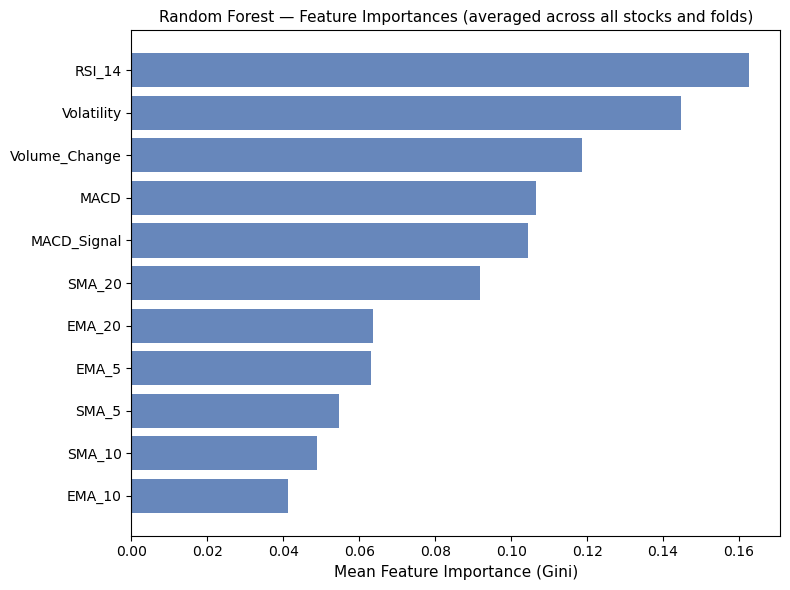

In [8]:
avg_importances = feature_importances / (len(TICKERS) * 5)
importance_df   = pd.DataFrame({
    "Feature"   : FEATURE_COLS,
    "Importance": avg_importances
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="#4C72B0", alpha=0.85)
ax.set_xlabel("Mean Feature Importance (Gini)", fontsize=11)
ax.set_title("Random Forest — Feature Importances (averaged across all stocks and folds)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "rf_feature_importance.png"), dpi=120, bbox_inches="tight")
plt.show()

## 7. Predicted vs actual returns

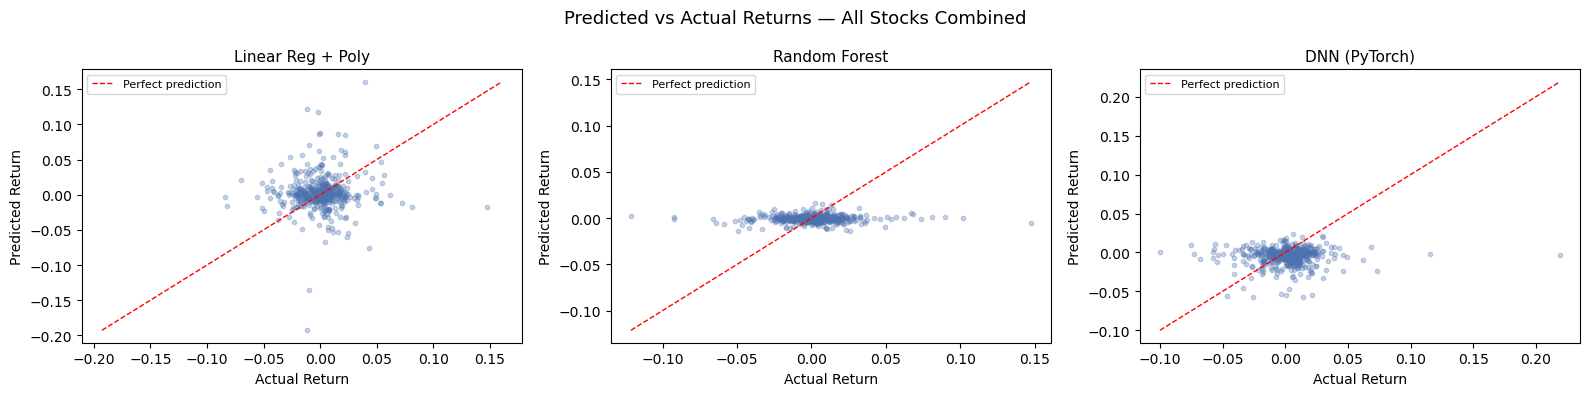

Notebook 05 complete — regression results saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_true, y_pred) in zip(axes, [
    ("Linear Reg + Poly", all_y_true_lr,  all_y_pred_lr),
    ("Random Forest",     all_y_true_rf,  all_y_pred_rf),
    ("DNN (PyTorch)",     all_y_true_dnn, all_y_pred_dnn),
]):
    idx  = np.random.choice(len(y_true), size=min(500, len(y_true)), replace=False)
    yt   = np.array(y_true)[idx]
    yp   = np.array(y_pred)[idx]
    ax.scatter(yt, yp, alpha=0.3, s=10, color="#4C72B0")
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual Returns — All Stocks Combined", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "regression_pred_vs_actual.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Notebook 05 complete — regression results saved.")